# 🏦 Loan Approval Prediction System

### Machine Learning Project

**Prepared By: Narendra Choudhary**

#  Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 📂 Step 2: Load the Dataset

In [2]:
df = pd.read_csv("Dataset.csv")

#  Step 3: Explore the Dataset

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


#  Step 4: Data Cleaning

In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [8]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

#  Step 5: Remove Unnecessary Columns

In [9]:
df.drop("Loan_ID",axis=1,inplace=True)

# 🔄 Step 6: Encode Categorical Features

In [18]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [19]:

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


#  Step 7: Exploratory Data Analysis (EDA)

In [20]:
X = df.drop("Loan_Status",axis=1)

y = df["Loan_Status"]

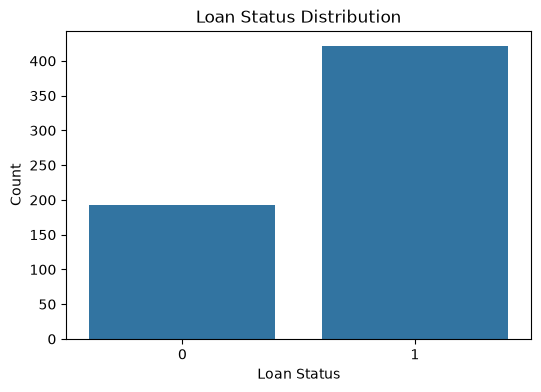

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(x="Loan_Status", data=df)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

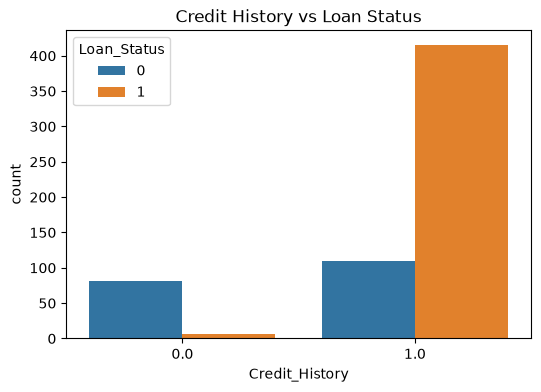

In [48]:
# 📊 Credit History vs Loan Status
plt.figure(figsize=(6,4))

sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)

plt.title("Credit History vs Loan Status")

plt.show()

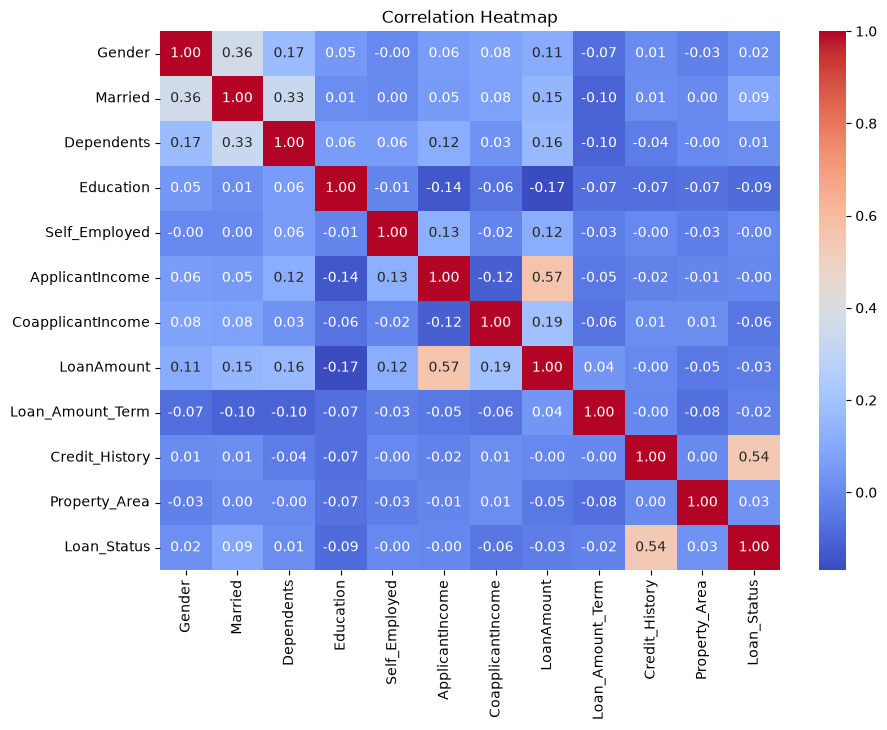

In [49]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

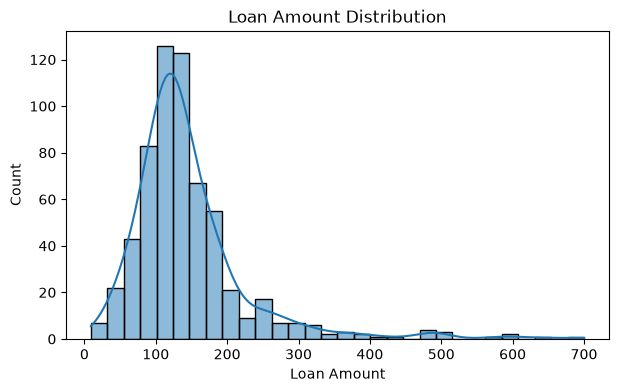

In [50]:
plt.figure(figsize=(7,4))

sns.histplot(
    df["LoanAmount"],
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")

plt.xlabel("Loan Amount")

plt.show()

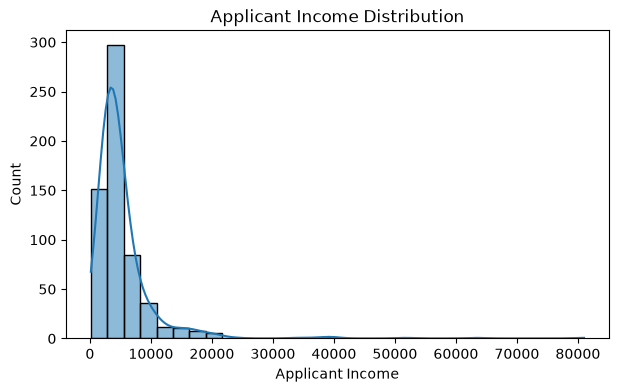

In [51]:
plt.figure(figsize=(7,4))

sns.histplot(
    df["ApplicantIncome"],
    bins=30,
    kde=True
)

plt.title("Applicant Income Distribution")

plt.xlabel("Applicant Income")

plt.show()

#  Step 8: Split the Dataset

In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#  Step 9: Feature Scaling

In [52]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 🤖 Step 10: Train Logistic Regression Model

In [23]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)


print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test,lr_pred)
)

Logistic Regression Accuracy: 0.7886178861788617


#  Step 11: Model Evaluation

In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [28]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.75      0.42      0.54        43
           1       0.75      0.93      0.83        80

    accuracy                           0.75       123
   macro avg       0.75      0.67      0.68       123
weighted avg       0.75      0.75      0.73       123



# Step 12: Confusion Matrix

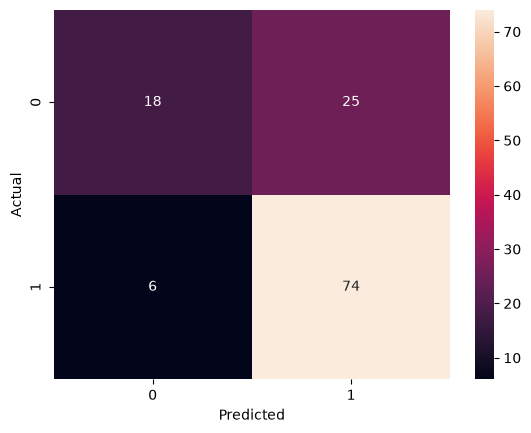

In [29]:
cm = confusion_matrix(
    y_test,
    rf_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Step 13: Loan Prediction Function

In [42]:
def predict_loan(
    gender,
    married,
    dependents,
    education,
    self_employed,
    applicant_income,
    coapplicant_income,
    loan_amount,
    loan_term,
    credit_history,
    property_area
):

    # Convert text to numbers
    gender = 1 if gender.lower() == "male" else 0

    married = 1 if married.lower() == "yes" else 0

    education = 0 if education.lower() == "graduate" else 1

    self_employed = 1 if self_employed.lower() == "yes" else 0

    credit_history = 1 if credit_history.lower() == "yes" else 0

    dependents_map = {
        "0": 0,
        "1": 1,
        "2": 2,
        "3+": 3
    }

    property_map = {
        "Rural": 0,
        "Semiurban": 1,
        "Urban": 2
    }

    dependents = dependents_map[dependents]
    property_area = property_map[property_area]

    input_data = [[
        gender,
        married,
        dependents,
        education,
        self_employed,
        applicant_income,
        coapplicant_income,
        loan_amount,
        loan_term,
        credit_history,
        property_area
    ]]

    input_df = pd.DataFrame(input_data, columns=X.columns)

    input_scaled = scaler.transform(input_df)

    prediction = lr.predict(input_scaled)
    probability = lr.predict_proba(input_scaled)

    if prediction[0] == 1:
        print("✅ Loan Approved")
    else:
        print("❌ Loan Rejected")

    print("Confidence:", round(max(probability[0]) * 100, 2), "%")

# ✅ Step 14: Test the Model

In [44]:
predict_loan(
    gender="Male",
    married="Yes",
    dependents="0",
    education="Graduate",
    self_employed="No",
    applicant_income=10000,
    coapplicant_income=2000,
    loan_amount=200,
    loan_term=300,
    credit_history="Yes",
    property_area="Urban"
)

✅ Loan Approved
Confidence: 82.18 %


# 🎉 Conclusion

## Project Summary

The **Loan Approval Prediction System** was successfully developed using Machine Learning techniques. The project analyzes applicant information such as income, education, credit history, loan amount, and property area to predict whether a loan application is likely to be **approved** or **rejected**.

The complete machine learning pipeline, including data preprocessing, exploratory data analysis, feature encoding, model training, and prediction, was implemented successfully.

---

## Key Achievements

- ✅ Loaded and explored the loan prediction dataset.
- ✅ Cleaned the dataset by handling missing values and removing unnecessary columns.
- ✅ Encoded categorical features into numerical values.
- ✅ Performed Exploratory Data Analysis (EDA) using various visualizations.
- ✅ Split the dataset into training and testing sets.
- ✅ Applied feature scaling to improve model performance.
- ✅ Built and trained a **Logistic Regression** model for loan prediction.
- ✅ Evaluated the model using **Accuracy Score**, **Classification Report**, and **Confusion Matrix**.
- ✅ Developed a user-friendly prediction function that accepts applicant details and predicts loan approval.

---

## Business Impact

This model can help banks and financial institutions make faster and more consistent loan approval decisions. It can also assist loan officers in identifying high-risk applications and reducing manual effort during the loan evaluation process.

---

## Future Improvements

- 🌳 Implement additional Machine Learning models such as Decision Tree, Random Forest, and XGBoost.
- 📊 Improve prediction accuracy through feature engineering and hyperparameter tuning.
- 🌐 Develop an interactive web application using **Streamlit** or **Flask**.
- ☁️ Deploy the trained model on a cloud platform for real-time loan prediction.
- 💾 Save and reuse the trained model using **Joblib** or **Pickle**.
- 📈 Add more business dashboards and advanced visualizations for better decision-making.

---

## Final Outcome

This project demonstrates a complete end-to-end Machine Learning workflow, from data preprocessing to model deployment readiness. It provides a practical solution for predicting loan approval and serves as a strong portfolio project for Data Analytics and Machine Learning roles.